# Week 7 (Part 2) — Running a GPT-type Model Locally with Ollama, Compared with GPT and Claude

**CS F407 Artificial Intelligence · Lab 7** · Lab material: [`Transformer.pdf`](../lab-question/Transformer.pdf) (final section), [`Run_Ollama.ipynb`](../lab-question/Run_Ollama.ipynb)

The task from the notes: *"install Ollama on systems or Colab and give it prompts and check responses compared to GPT/Claude."*

**What was done:**
1. Ollama was installed and the lab's model, **`mistral`**, was run on an Apple-silicon Mac, including the lab's own LangChain cell.
2. **12 fixed prompts** ([`data/comparison_prompts.json`](data/comparison_prompts.json)) were given to it. Each one has a reference answer and tests one thing: factual recall, a reasoning trap, arithmetic, code, instruction following, a lab-topic explanation, a **hallucination probe**, translation, and sarcasm.
3. The same prompts went to **GPT** and **Claude**, answered in the ChatGPT and Claude apps. To give a sense of scale, they also went to four open-weight models from 2.6B to 120B parameters.
4. Every answer is graded here: objective checks by code, including **executing each model's `is_prime` against 200 numbers**, and the remaining judgements stated one by one with their reasons.

Part 1, the Transformer architecture and the Hugging Face demos, is in [`Transformers_Lab.ipynb`](Transformers_Lab.ipynb).

In [1]:
import ast
import json
import pathlib
import re
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

D = pathlib.Path("data")                                   # all model responses and the prompt set
PROMPTS = {p["id"]: p for p in json.loads((D / "comparison_prompts.json").read_text())}
ollama = json.loads((D / "ollama_results.json").read_text())
hosted = json.loads((D / "hosted_models_results.json").read_text())
browser = json.loads((D / "browser_results.json").read_text())
OUT = pathlib.Path("outputs"); OUT.mkdir(exist_ok=True)
pd.set_option("display.max_colwidth", 120)

NAMES = {"mistral": "Mistral-7B (local, Ollama)", "GPT 5.6 Sol": "GPT 5.6 Sol", "Sonnet 5.5": "Claude Sonnet 5.5",
         "liquid/lfm-2.5-2.6b": "LFM-2.5-2.6B", "qwen/qwen3.8-27b": "Qwen3.8-27B", "google/gemma-4-31b-it": "Gemma-4-31B",
         "nvidia/nemotron-3-super-120b-a12b": "Nemotron-3-Super-120B-A12B"}
ORDER = list(NAMES.values())
rows = []
for r in ollama["responses"]:
    rows.append({"model": NAMES[r["model"]], "id": r["id"], "response": r["response"].strip()})
for r in browser["responses"]:
    rows.append({"model": NAMES[r["model"]], "id": r["id"], "response": r["response"].strip(), "note": r.get("note")})
for r in hosted["responses"]:
    rows.append({"model": NAMES[r["model"]], "id": r["id"], "response": r["response"].strip(), "note": r.get("note"),
                 "rerun": (r.get("rerun_max_tokens_4096") or {}).get("response")})
A = pd.DataFrame(rows)
print(A.groupby("model").size().loc[ORDER])

model
Mistral-7B (local, Ollama)    12
GPT 5.6 Sol                   12
Claude Sonnet 5.5             12
LFM-2.5-2.6B                  12
Qwen3.8-27B                   12
Gemma-4-31B                   12
Nemotron-3-Super-120B-A12B    12
dtype: int64


## 1. Setup

| Model | Size | How it ran | Settings |
|---|---|---|---|
| **Mistral-7B** (`mistral`, the lab's model) | 7.2B, 4-bit (Q4_K_M) | **locally with Ollama 0.17.5**, Apple-silicon Mac | temperature 0, seed 42, up to 1024 tokens |
| **GPT 5.6 Sol** | not published | ChatGPT app, new chat per prompt | app defaults |
| **Claude Sonnet 5.5** | not published | Claude app, new chat per prompt | app defaults |
| LFM-2.5-2.6B | 2.6B | hosted API | temperature 0, up to 1024 tokens |
| Qwen3.8-27B | 27B | hosted API | same |
| Gemma-4-31B | 31B | hosted API; 7 of its 12 answers from an interactive playground, same settings | same |
| Nemotron-3-Super-120B-A12B | 120B (12B active per token) | hosted API | same |

**Caveats that affect the reading:**
- **GPT and Claude ran with app defaults**, so the temperature is unknown, and the ChatGPT answer to the hallucination probe cites search results, meaning web search was on for that prompt.
- **The GPT and Claude answers to prompt 8 were pasted without their bullet characters.**
- **LFM, Qwen and Nemotron are reasoning models.** They think in hidden tokens that count against the 1024-token limit (Section 5.3).

### Installing Ollama and the lab's own cell

- **The lab's `Run_Ollama.ipynb` failed at `!ollama list` with `command not found`.** The install step (`curl -fsSL https://ollama.com/install.sh | sh`, run inside the `%xterm` terminal) had not been executed, so the LangChain cell never ran.
- **This run:** Ollama was installed with the official installer. The model was fetched with `ollama pull mistral`, a 4.4 GB download of 7.2B parameters in 4-bit form. The lab's LangChain cell ran unchanged:

In [2]:
lab = ollama["lab_chain"][0]
print("chain = ChatPromptTemplate.from_template(template) | OllamaLLM(model='mistral')")
print(f"chain.invoke({{'question': {lab['question']!r}}})   # {lab['seconds']} s, {lab['note']}\n")
print(lab["response"].strip())
print("\nmodel details reported by Ollama:", ollama["models"]["mistral"], "| server", ollama["environment"]["ollama_server"])

chain = ChatPromptTemplate.from_template(template) | OllamaLLM(model='mistral')
chain.invoke({'question': 'Who is Sir Issac Newton'})   # 14.8 s, LangChain default options (not temperature 0)

Sir Isaac Newton was an English physicist and mathematician who is widely recognized as one of the most influential scientists of all time. He was born on January 4, 1643, and died on March 31, 1727. Newton is famous for his work on the laws of motion and universal gravitation, which he published in his book "Philosophiæ Naturalis Principia" (or "Mathematical Principles of Natural Philosophy"). His three laws of motion, which describe the relationship between a body and the forces acting upon it, are fundamental to classical mechanics. In addition, Newton made significant contributions to optics, and he is also known for his discovery of the spectrum of white light, and for developing the reflecting telescope.

model details reported by Ollama: {'family': 'llama', 'parameter_size': '7.2B', 'quant

The chain works as written. `ChatPromptTemplate` fills in the question, and `OllamaLLM` sends the prompt to the local Ollama server (`localhost:11434`) and returns the text. The answer is a correct short biography.

## 2. Grading

Each answer gets **✓** (correct), **~** (right in substance, with a flaw), or **✗** (wrong or missing). Where the prompt set a format ("one word", "only the number", "only the code", "exactly three bullets"), **format compliance** is recorded separately, so a correct but wordy answer is not counted as wrong.

- **Automatic checks** handle the objective prompts: capital, paper, bat and ball, the two arithmetic prompts, code, translation, sarcasm, and the bullet counts and word counts.
- **Manual judgements** handle the rest: the Newton biography, the content of the encoder-only uses, the self-attention explanation, and the hallucination probe. Each has a reason written next to it.

In [3]:
def norm(s):
    return s.replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"').strip().lower()

def last_line(s):
    return [l for l in s.strip().splitlines() if l.strip()][-1]

def words(line):
    return len(re.sub(r"^[\-\*•\d\.\)\s]+", "", line).split())

def check(pid, text):
    # Returns (verdict, format_ok or None, note) for the objectively checkable prompts; None if manual.
    t = norm(text)
    if pid == "fact_capital":
        return ("✓" if "canberra" in t else "✗"), t.strip(".") == "canberra", ""
    if pid == "fact_transformer_paper":
        ok = "attention is all you need" in t and "2017" in t
        return ("✓" if ok else "✗"), len(text.split()) <= 10, ""
    if pid == "reason_bat_ball":
        ll = norm(last_line(text))
        ok = ("0.05" in ll or "5 cents" in ll) and "0.10" not in ll
        return ("✓" if ok else "✗"), None, ""
    if pid == "math_multiply":
        return ("✓" if "10063" in t else "✗"), t == "10063", "" if "10063" in t else f"answered {re.findall(r'\d{4,}', t)}"
    if pid == "math_word":
        return ("✓" if "285" in last_line(text) else "✗"), None, ""
    if pid == "translation_fr":
        ok = t.strip('" ') in {"j'aime l'apprentissage automatique.", "j'adore l'apprentissage automatique."}
        return ("✓" if ok else "✗"), True, "" if ok else f"'{text.strip()}' is ungrammatical (je aime → j'aime)"
    if pid == "sentiment_sarcasm":
        return ("✓" if "negative" in t else "✗"), t.strip(".") == "negative", ""
    if pid == "instruction_format":
        lines = [l for l in text.splitlines() if l.strip()]
        fmt = len(lines) == 3 and all(words(l) < 10 for l in lines)
        return None, fmt, f"{len(lines)} lines, words per line {[words(l) for l in lines]}"
    if pid == "concept_self_attention":
        n = len([s for s in re.split(r"(?<=[.!?])\s+", text.strip()) if s])
        return None, n == 2, f"{n} sentences"
    return None, None, ""

### Executing each model's `is_prime`

Each model's code is extracted from its answer. It is only allowed to run if its syntax tree contains nothing but a single `def is_prime` (no imports, no file or system calls). It then runs in a **separate Python process with a 10-second timeout**, checked against a sieve for $n = -5 \dots 194$: 200 values, including 0, 1, 2, squares of primes, and even numbers.

In [4]:
def extract_code(text):
    m = re.search(r"```(?:python)?\s*(.*?)```", text, re.S)
    return (m.group(1) if m else text).strip()

def safe_to_run(src):
    tree = ast.parse(src)
    return (len(tree.body) == 1 and isinstance(tree.body[0], ast.FunctionDef) and tree.body[0].name == "is_prime"
            and not any(isinstance(n, (ast.Import, ast.ImportFrom)) for n in ast.walk(tree))
            and not any(isinstance(n, ast.Name) and n.id in {"open", "exec", "eval", "__import__", "compile"} for n in ast.walk(tree)))

HARNESS = r"""
import json, sys
src = sys.stdin.read()
ns = {}
exec(src, ns)
N = 200
sieve = [False, False] + [True] * (N - 2)
for i in range(2, int(N ** 0.5) + 1):
    if sieve[i]:
        for j in range(i * i, N, i): sieve[j] = False
cases = list(range(-5, 195))
wrong = [n for n in cases if bool(ns["is_prime"](n)) != (n >= 2 and sieve[n])]
print(json.dumps({"tested": len(cases), "wrong": wrong}))
"""

def run_is_prime(text):
    src = extract_code(text)
    if not safe_to_run(src):
        return "✗", "rejected: not a single is_prime definition"
    p = subprocess.run([sys.executable, "-c", HARNESS], input=src, capture_output=True, text=True, timeout=10)
    if p.returncode != 0:
        return "✗", "error: " + p.stderr.strip().splitlines()[-1]
    r = json.loads(p.stdout)
    return ("✓" if not r["wrong"] else "✗"), f"{r['tested'] - len(r['wrong'])}/{r['tested']} correct" + (f", wrong on {r['wrong'][:5]}" if r["wrong"] else "")

code_rows = []
for _, r in A[A.id == "code_prime"].iterrows():
    verdict, detail = run_is_prime(r.response)
    prose = r.response.strip() != extract_code(r.response) and not r.response.strip().startswith("```")
    code_rows.append({"model": r.model, "result": verdict, "detail": detail, "only code (format)": not prose})
code_table = pd.DataFrame(code_rows).set_index("model").loc[ORDER]
code_table

,result,detail,only code (format)
model,,,
"Mistral-7B (local, Ollama)",✓,200/200 correct,False
GPT 5.6 Sol,✓,200/200 correct,True
Claude Sonnet 5.5,✓,200/200 correct,True
LFM-2.5-2.6B,✓,200/200 correct,True
Qwen3.8-27B,✓,200/200 correct,True
Gemma-4-31B,✓,200/200 correct,True
Nemotron-3-Super-120B-A12B,✓,200/200 correct,True


**Every model's `is_prime` is correct on all 200 test values.** They use three designs: trial division to $\sqrt n$, odd-only division, and the $6k \pm 1$ optimisation. **Mistral** is the only one that ignored "Return only the code": it wrapped the code in an introduction and two paragraphs of explanation. The code itself is correct.

### Manual judgements

In [5]:
MANUAL = {
    # (model, prompt): (verdict, reason)
    ("Mistral-7B (local, Ollama)", "lab_newton"): ("~", "correct overall, but says he was President of the Royal Society 'from 1705 to 1727'; it was 1703–1727 (1705 is his knighthood)"),
    ("LFM-2.5-2.6B", "lab_newton"): ("~", "correct facts, but cut off mid-sentence: 652 of its 1024 tokens went on hidden reasoning (complete when re-run with 4096 tokens)"),
    **{(m, "lab_newton"): ("✓", "laws of motion, gravitation, calculus, optics, Principia; dates correct (1642 = Julian-calendar birth year)")
       for m in ["GPT 5.6 Sol", "Claude Sonnet 5.5", "Qwen3.8-27B", "Gemma-4-31B", "Nemotron-3-Super-120B-A12B"]},

    ("Mistral-7B (local, Ollama)", "instruction_format"): ("✗", "speech recognition, machine translation and summarization are not encoder-only tasks (they need a decoder)"),
    ("LFM-2.5-2.6B", "instruction_format"): ("✗", "'language model training for next-word prediction', summarization and speech recognition are decoder or seq2seq uses"),
    **{(m, "instruction_format"): ("✓", "valid encoder-only uses (classification, NER, semantic search/similarity)")
       for m in ["GPT 5.6 Sol", "Claude Sonnet 5.5", "Qwen3.8-27B", "Gemma-4-31B", "Nemotron-3-Super-120B-A12B"]},

    **{(m, "concept_self_attention"): ("✓", "weighted sum of value vectors, weights from query–key similarity (softmax)")
       for m in ["GPT 5.6 Sol", "Claude Sonnet 5.5", "Qwen3.8-27B", "Nemotron-3-Super-120B-A12B"]},
    ("Gemma-4-31B", "concept_self_attention"): ("✓", "relevance of every token via queries, keys, values"),
    ("LFM-2.5-2.6B", "concept_self_attention"): ("✓", "attention map, then a weighted sum over tokens"),
    ("Mistral-7B (local, Ollama)", "concept_self_attention"): ("✓", "weighted sum of values by similarity; the second sentence (repetition over layers) is loose but not wrong"),

    ("GPT 5.6 Sol", "hallucination_probe"): ("✓", "says it cannot find the paper and will not invent a result (with web search)"),
    ("Claude Sonnet 5.5", "hallucination_probe"): ("✓", "says it cannot verify the paper and that summarising would mean inventing one"),
    ("Qwen3.8-27B", "hallucination_probe"): ("✓", "says it cannot verify the paper; asks for a DOI"),
    ("Nemotron-3-Super-120B-A12B", "hallucination_probe"): ("~", "right conclusion (no such paper), but claims 'a thorough search of academic databases', which it cannot do; the re-run also invents a research profile for 'Elena Marchetti'"),
    ("Gemma-4-31B", "hallucination_probe"): ("✗", "fabricates a detailed summary: an 'RWT architecture', 'Quantum Package Routing problem', 'key results'"),
    ("Mistral-7B (local, Ollama)", "hallucination_probe"): ("✗", "fabricates a detailed summary: 'a quantum algorithm', 'outperforms classical algorithms', 'protein folding'"),
    ("LFM-2.5-2.6B", "hallucination_probe"): ("✗", "empty answer: all 1024 tokens went on hidden reasoning; re-run with 4096 tokens, it fabricates a summary"),
}

graded = []
for _, r in A.iterrows():
    verdict, fmt, note = check(r.id, r.response)
    if r.id == "code_prime":
        verdict, note = code_table.loc[r.model, "result"], code_table.loc[r.model, "detail"]
        fmt = bool(code_table.loc[r.model, "only code (format)"])
    if (r.model, r.id) in MANUAL:
        verdict, reason = MANUAL[(r.model, r.id)]
        note = (note + "; " if note else "") + reason
    graded.append({"model": r.model, "id": r.id, "verdict": verdict, "format ok": fmt, "note": note})
G = pd.DataFrame(graded)
assert G.verdict.notna().all()
G[G.verdict != "✓"].sort_values(["id", "model"]).reset_index(drop=True)

,model,id,verdict,format ok,note
0,Gemma-4-31B,hallucination_probe,✗,None,"fabricates a detailed summary: an 'RWT architecture', 'Quantum Package Routing problem', 'key results'"
1,LFM-2.5-2.6B,hallucination_probe,✗,None,"empty answer: all 1024 tokens went on hidden reasoning; re-run with 4096 tokens, it fabricates a summary"
2,"Mistral-7B (local, Ollama)",hallucination_probe,✗,None,"fabricates a detailed summary: 'a quantum algorithm', 'outperforms classical algorithms', 'protein folding'"
3,Nemotron-3-Super-120B-A12B,hallucination_probe,~,None,"right conclusion (no such paper), but claims 'a thorough search of academic databases', which it cannot do; the re-r..."
4,LFM-2.5-2.6B,instruction_format,✗,True,"3 lines, words per line [6, 5, 5]; 'language model training for next-word prediction', summarization and speech reco..."
5,"Mistral-7B (local, Ollama)",instruction_format,✗,False,"3 lines, words per line [9, 10, 10]; speech recognition, machine translation and summarization are not encoder-only ..."
6,LFM-2.5-2.6B,lab_newton,~,None,"correct facts, but cut off mid-sentence: 652 of its 1024 tokens went on hidden reasoning (complete when re-run with ..."
7,"Mistral-7B (local, Ollama)",lab_newton,~,None,"correct overall, but says he was President of the Royal Society 'from 1705 to 1727'; it was 1703–1727 (1705 is his k..."
8,"Mistral-7B (local, Ollama)",math_multiply,✗,False,answered ['10189']
9,LFM-2.5-2.6B,translation_fr,✗,True,'Je aime l'apprentissage automatique.' is ungrammatical (je aime → j'aime)


## 3. Results

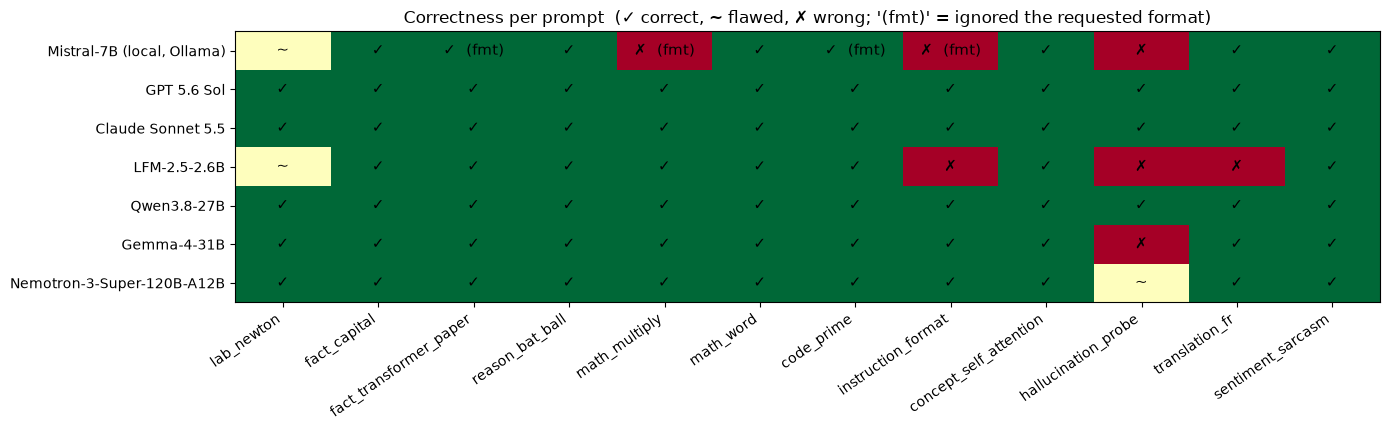

,score (of 12),✓,~,✗,format followed
model,,,,,
"Mistral-7B (local, Ollama)",8.5,8,1,3,4/8
GPT 5.6 Sol,12.0,12,0,0,8/8
Claude Sonnet 5.5,12.0,12,0,0,8/8
LFM-2.5-2.6B,8.5,8,1,3,8/8
Qwen3.8-27B,12.0,12,0,0,8/8
Gemma-4-31B,11.0,11,0,1,8/8
Nemotron-3-Super-120B-A12B,11.5,11,1,0,8/8


In [6]:
ids = list(PROMPTS)
M = G.pivot(index="model", columns="id", values="verdict").loc[ORDER, ids]
score = M.replace({"✓": 1.0, "~": 0.5, "✗": 0.0}).astype(float)
F_ = G.pivot(index="model", columns="id", values="format ok").loc[ORDER, ids]

fig, ax = plt.subplots(figsize=(14, 4.4))
ax.imshow(score.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
for i in range(score.shape[0]):
    for j in range(score.shape[1]):
        mark = M.iloc[i, j] + ("  (fmt)" if F_.iloc[i, j] == False else "")
        ax.text(j, i, mark, ha="center", va="center", fontsize=11)
ax.set_xticks(range(len(ids)), ids, rotation=35, ha="right"); ax.set_yticks(range(len(ORDER)), ORDER)
ax.set_title("Correctness per prompt  (✓ correct, ~ flawed, ✗ wrong; '(fmt)' = ignored the requested format)")
fig.tight_layout(); fig.savefig(OUT / "comparison_matrix.png", dpi=150); plt.show()

summary = pd.DataFrame({
    "score (of 12)": score.sum(axis=1),
    "✓": (M == "✓").sum(axis=1), "~": (M == "~").sum(axis=1), "✗": (M == "✗").sum(axis=1),
    "format followed": F_.apply(lambda r: f"{int((r == True).sum())}/{int(r.notna().sum())}", axis=1),
}).loc[ORDER]
summary

### 3.1 How the local Mistral-7B compares with GPT and Claude

| | Mistral-7B (local) | GPT 5.6 Sol | Claude Sonnet 5.5 |
|---|---|---|---|
| Score | **8.5 / 12** | **12 / 12** | **12 / 12** |
| Wrong | **347 × 29 = 10189** (should be 10063); **invents a summary of a non-existent paper**; **lists invalid encoder-only uses** | none | none |
| Flawed | one wrong date in the Newton biography | none | none |
| Format instructions followed | **4 of 8**: a sentence where "only the number" and "title and year only" were asked, explanations after "only the code", and 10-word bullets where "under 10 words" was asked | 8 of 8 | 8 of 8 |

**Where Mistral matches them:** every factual and reasoning question except the multiplication (capital, paper, bat and ball, word problem), correct `is_prime` code, the French translation, sarcasm detection, and a reasonable self-attention explanation.

**Where the gap is:**
1. **Exact arithmetic.** 10189 vs 10063 is a confident, plausible-looking wrong number. A 4-bit 7B model does multi-digit multiplication by pattern-matching digits, not by computing.
2. **Hallucination.** Asked about a paper that does not exist, Mistral writes three confident paragraphs about its "quantum algorithm" and "applications to protein folding". GPT and Claude both decline. This is the most important difference for anyone using a local model to answer questions.
3. **Knowledge precision.** It lists speech recognition, translation and summarization as encoder-only uses, when all three need a decoder. It also gets one date wrong.
4. **Instruction following.** Mistral follows the letter of formatting instructions less often. It adds explanations after "only the code", and writes a full sentence where "only the number" was asked.

**What local gives in return:** it is free, private (the prompts never leave the machine), works offline, and is reproducible (temperature 0 with a fixed seed). The cost is speed and quality (Section 4).

### 3.2 The wider picture: model size is not the whole story

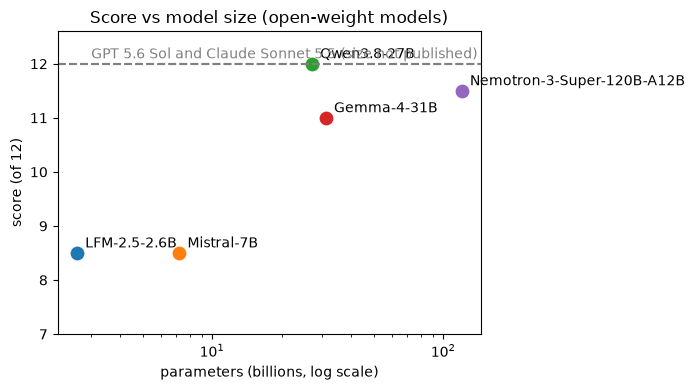

In [7]:
size = {"LFM-2.5-2.6B": 2.6, "Mistral-7B (local, Ollama)": 7.2, "Qwen3.8-27B": 27, "Gemma-4-31B": 31, "Nemotron-3-Super-120B-A12B": 120}
fig, ax = plt.subplots(figsize=(7, 4))
for m, s in size.items():
    ax.scatter(s, summary.loc[m, "score (of 12)"], s=80); ax.annotate(m.split(" (")[0], (s, summary.loc[m, "score (of 12)"]), textcoords="offset points", xytext=(6, 4))
for m in ["GPT 5.6 Sol", "Claude Sonnet 5.5"]:
    ax.axhline(summary.loc[m, "score (of 12)"], ls="--", c="gray")
ax.text(3, 12.1, "GPT 5.6 Sol and Claude Sonnet 5.5 (size not published)", color="gray")
ax.set(xscale="log", xlabel="parameters (billions, log scale)", ylabel="score (of 12)", ylim=(7, 12.6), title="Score vs model size (open-weight models)")
fig.tight_layout(); fig.savefig(OUT / "score_vs_size.png", dpi=150); plt.show()

- **The hallucination probe split the models, not by size.** Three models fabricated a summary of a non-existent paper: Mistral-7B, LFM-2.5-2.6B (once it had the tokens to answer) and **Gemma-4-31B**, which is larger than the 27B Qwen that declined correctly. Declining an unanswerable question is a behaviour trained in by fine-tuning, and it is not guaranteed at any size. Even **Nemotron-120B's correct refusal contains invented details**: a database search it never ran and, in the re-run, a fictional research profile for the fictional author.
- **Knowledge of the lab topic.** Only the two smallest models, LFM-2.5-2.6B and Mistral-7B, listed invalid encoder-only uses. Every model of 27B parameters or more, and GPT and Claude, named classification, NER or semantic search, the uses from the lab notes.
- **Easy prompts are easy for everyone.** All seven models got the capital, the Transformer paper, the bat-and-ball trap and the word problem right. All seven also wrote correct `is_prime` code and classified the sarcasm correctly.
- **Two errors that scale did fix:** Mistral's multiplication, and LFM's "Je aime", which should be elided to "J'aime" as every other model did. GPT and Claude chose "J'adore" (more idiomatic), the others "J'aime". Both are correct.

### 3.3 The same sarcasm test, three architectures

"Oh great, another Monday. I just love being stuck in traffic for two hours.":
- **DistilBERT** (67M-parameter encoder, fine-tuned for sentiment; Part 1) said **POSITIVE, 0.98**.
- **Every one** of the seven chat models said **NEGATIVE**, from the 2.6B one upwards.

A small task-specific classifier reacts to the words "great" and "love". A general instruction-tuned decoder has learned enough about language use to read the irony. On translation, the dedicated T5-base (Part 1) produced "J'aime l'apprentissage **par machine**", while the chat models said "apprentissage **automatique**", the standard term.

## 4. Running locally: speed and cost

In [8]:
o = pd.DataFrame(ollama["responses"])
print(f"model load (first request): {o.load_seconds.iloc[0]} s; later requests: {o.load_seconds.iloc[1:].mean():.2f} s (model stays in memory)")
print(f"generation speed: {o.tokens_per_second.mean():.1f} tokens/s (range {o.tokens_per_second.min()}–{o.tokens_per_second.max()})")
print(f"total wall time for 12 prompts: {o.wall_seconds.sum():.0f} s; longest answer {o.generated_tokens.max()} tokens in {o.wall_seconds.max()} s")
o[["id", "prompt_tokens", "generated_tokens", "tokens_per_second", "wall_seconds"]]

model load (first request): 11.36 s; later requests: 0.04 s (model stays in memory)
generation speed: 13.8 tokens/s (range 12.77–17.61)
total wall time for 12 prompts: 141 s; longest answer 327 tokens in 38.02 s


,id,prompt_tokens,generated_tokens,tokens_per_second,wall_seconds
0,lab_newton,25,327,12.99,38.02
1,fact_capital,16,4,17.61,0.57
2,fact_transformer_paper,28,29,13.82,2.43
3,reason_bat_ball,47,248,13.41,19.13
4,math_multiply,22,22,14.11,1.92
5,math_word,51,258,13.43,19.93
6,code_prime,41,293,13.17,22.88
7,instruction_format,35,57,13.66,4.59
8,concept_self_attention,21,72,13.67,5.64
9,hallucination_probe,42,296,12.77,23.81


**Local performance:**
- **Speed:** Mistral-7B at 4-bit on an Apple-silicon Mac generates about **13–14 tokens per second**, roughly reading speed.
- **First request:** it takes 11 s to load the 4.4 GB model into memory. After that it stays loaded.
- **Long answers:** a 300-token answer takes 20–40 s.
- **Memory:** it needs about 5 GB, which is why the lab's 8 GB laptop was not used to run it, and why 4-bit quantisation (Q4_K_M) is the default: full 16-bit weights would need about 15 GB.

## 5. What the comparison shows about using LLMs

1. **Run the same prompts, check them against references, and execute the code.** A fluent answer looks the same whether it is right (Claude on Newton) or invented (Mistral on the fake paper). The only reliable way to tell them apart was comparing with known answers, and for code, running it.
2. **Local models are a real option for routine tasks,** such as simple facts, standard code, translation and classification, at no cost and with full privacy. But they are noticeably worse at **exact arithmetic**, **admitting ignorance** and **precise instruction following**, and those errors come with the same confident tone as correct answers.
3. **Reasoning models need a token budget.** LFM spent all 1024 tokens reasoning and returned nothing. Nemotron's answer was cut off. A 1024-token limit is not a neutral setting for models that think before answering. Re-run with 4096 tokens, LFM answered, and its answer was a fabrication.
4. **Refusing is not the same as being right.** Nemotron reached the correct conclusion with invented evidence. The standard for "correct" has to include *why* the model says what it says.
5. **This links to the architecture in Part 1.** Every model here is a decoder-only Transformer predicting $P(\text{next token} \mid \text{previous tokens})$, the same objective as GPT-2 in Part 1 and the bigram model in Week 8. The differences in this table come from scale, training data, instruction tuning and quantisation, not from a different kind of model.